# LAB 2.1 - Hebbian Learning Rules

Mandatory rules: Hebb, Oja, Subtractive normalization.
Bonus rules included: BCM and Covariance.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from hebbian_learning import (
    fit_rule,
    load_dataset,
    plot_points_with_vectors,
    plot_weight_trajectory,
    principal_eigenvector,
    save_history,
    zscore_per_feature,
)


Matplotlib is building the font cache; this may take a moment.


In [2]:
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
bcm_theta = float(np.random.uniform(0, 1))

rules_dataset1 = {
    "hebb": {"epochs": 1000, "lr": 0.01, "tol": 1e-4},
    "oja": {"epochs": 1000, "lr": 0.001, "tol": 1e-6, "alpha": 0.01},
    "subtractive": {"epochs": 1000, "lr": 0.001, "tol": 1e-5},
    "bcm": {"epochs": 10000, "lr": 0.0005, "tol": 1e-5, "theta0": bcm_theta},
    "covariance": {"epochs": 1000, "lr": 0.001, "tol": 1e-5},
}

rules_dataset2 = {
    "hebb": {"epochs": 10000, "lr": 1e-5, "tol": 1e-7},
    "oja": {"epochs": 10000, "lr": 0.001, "tol": 1e-6, "alpha": 0.01},
    "subtractive": {"epochs": 1000, "lr": 0.001, "tol": 1e-5},
    "bcm": {"epochs": 10000, "lr": 0.0005, "tol": 1e-5, "theta0": bcm_theta},
    "covariance": {"epochs": 1000, "lr": 0.001, "tol": 1e-5},
}


In [3]:
def inspect_dataset(data, title):
    plt.figure(figsize=(6, 4))
    plt.plot(data[0], data[1], "o", markersize=3, label="Data points")
    plt.xlabel("u[0]")
    plt.ylabel("u[1]")
    plt.title(title)
    plt.legend()
    plt.show()


def run_all_rules(dataset_name, data, rule_cfg, anchor=(0.0, 0.0), seed=42):
    pvec = principal_eigenvector(data)
    out = {}

    folder_map = {
        "hebb": "hebb_rule",
        "oja": "oja_rule",
        "subtractive": "sub_norm_rule",
        "bcm": "BCM_rule",
        "covariance": "covariance_rule",
    }

    for rule_name, cfg in rule_cfg.items():
        result = fit_rule(
            data=data,
            rule=rule_name,
            epochs=cfg["epochs"],
            lr=cfg["lr"],
            tol=cfg["tol"],
            seed=seed,
            alpha=cfg.get("alpha", 1e-2),
            theta0=cfg.get("theta0"),
        )
        out[rule_name] = result

        folder_name = folder_map[rule_name]
        rule_dir = RESULTS / dataset_name / folder_name
        fig_dir = FIGURES / dataset_name / folder_name
        rule_dir.mkdir(parents=True, exist_ok=True)
        fig_dir.mkdir(parents=True, exist_ok=True)

        save_history(result.history, rule_dir / "weights.npz")

        plot_points_with_vectors(
            data,
            result.final_w,
            pvec,
            title=folder_name.replace("_", " ") + " weights and principal eigenvector plot",
            output_path=fig_dir / "plot_1.png",
            anchor=anchor,
        )
        plot_weight_trajectory(
            result.history,
            title="Evolution of Weight Vector - " + folder_name.replace("_", " "),
            output_path=fig_dir / "plot_2.png",
        )

        print(
            f"[{dataset_name} | {folder_name}] "
            f"convergence epoch={result.convergence_epoch} | final_w={np.round(result.final_w, 4)}"
        )

    return out


## Dataset 1


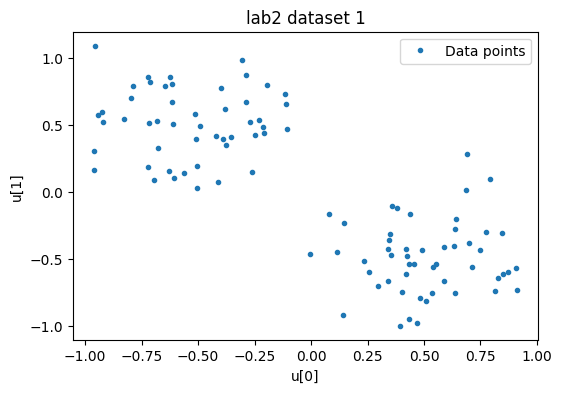

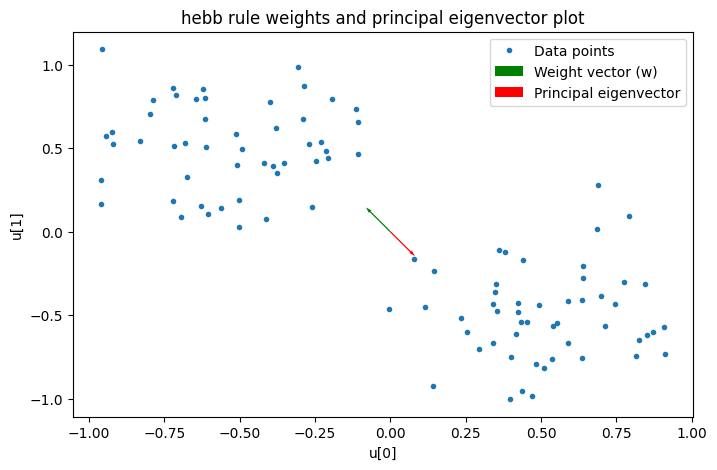

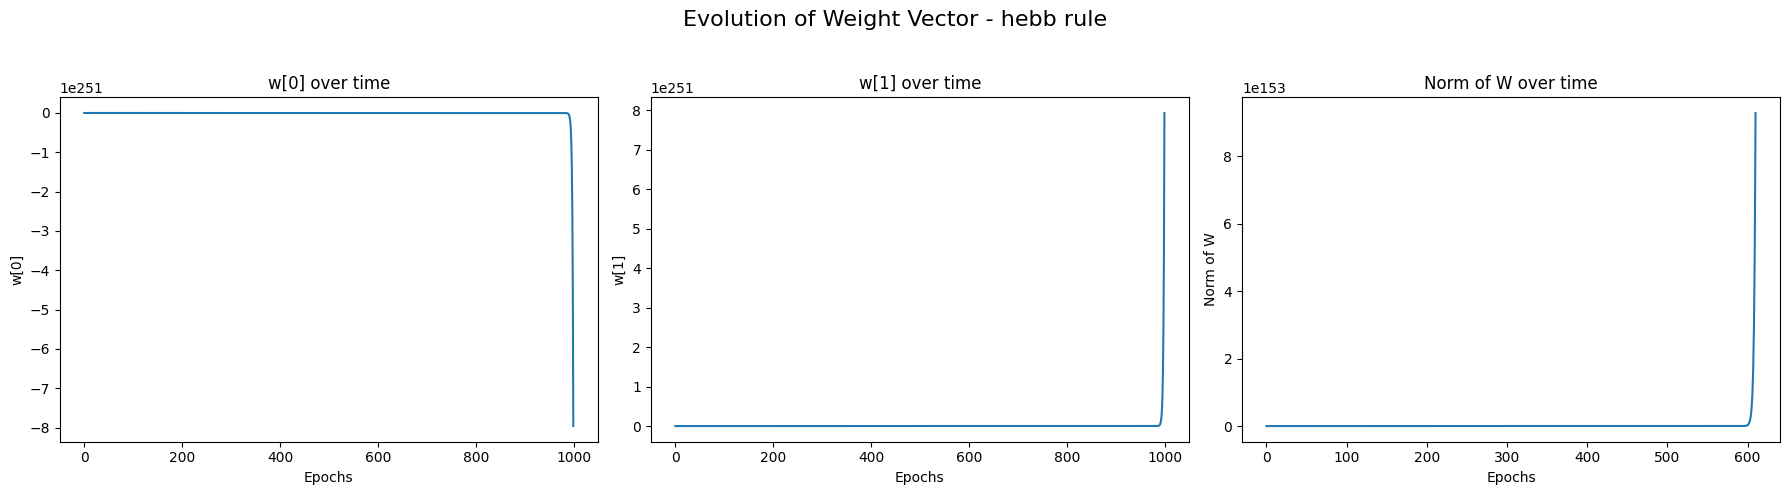

[dataset_1 | hebb_rule] convergence epoch=1000 | final_w=[-7.96239703e+251  7.92748025e+251]


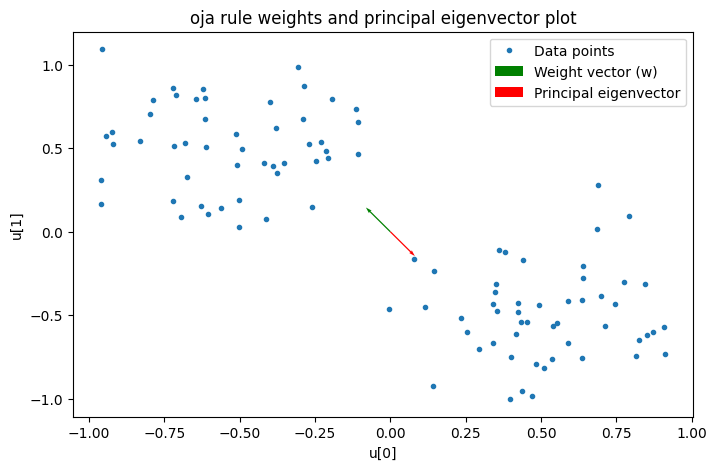

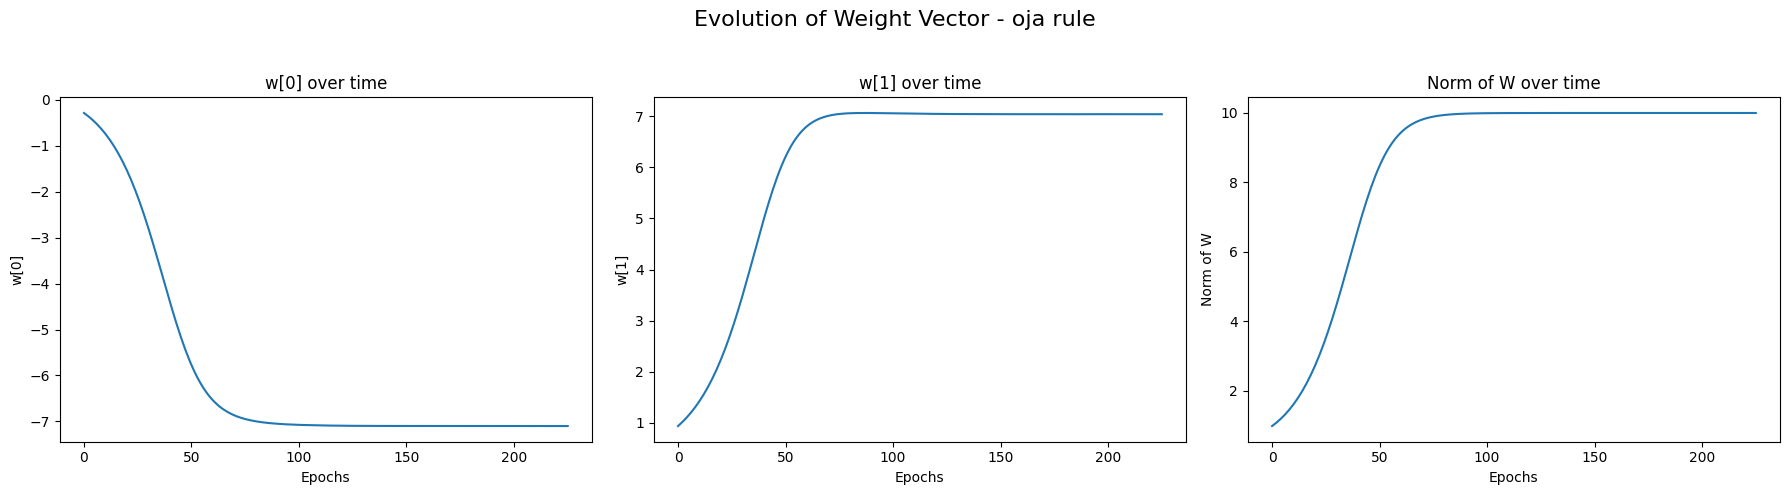

[dataset_1 | oja_rule] convergence epoch=226 | final_w=[-7.1027  7.0395]


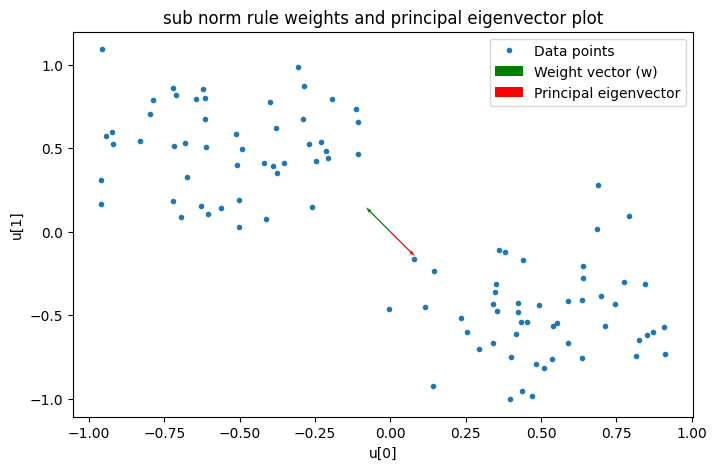

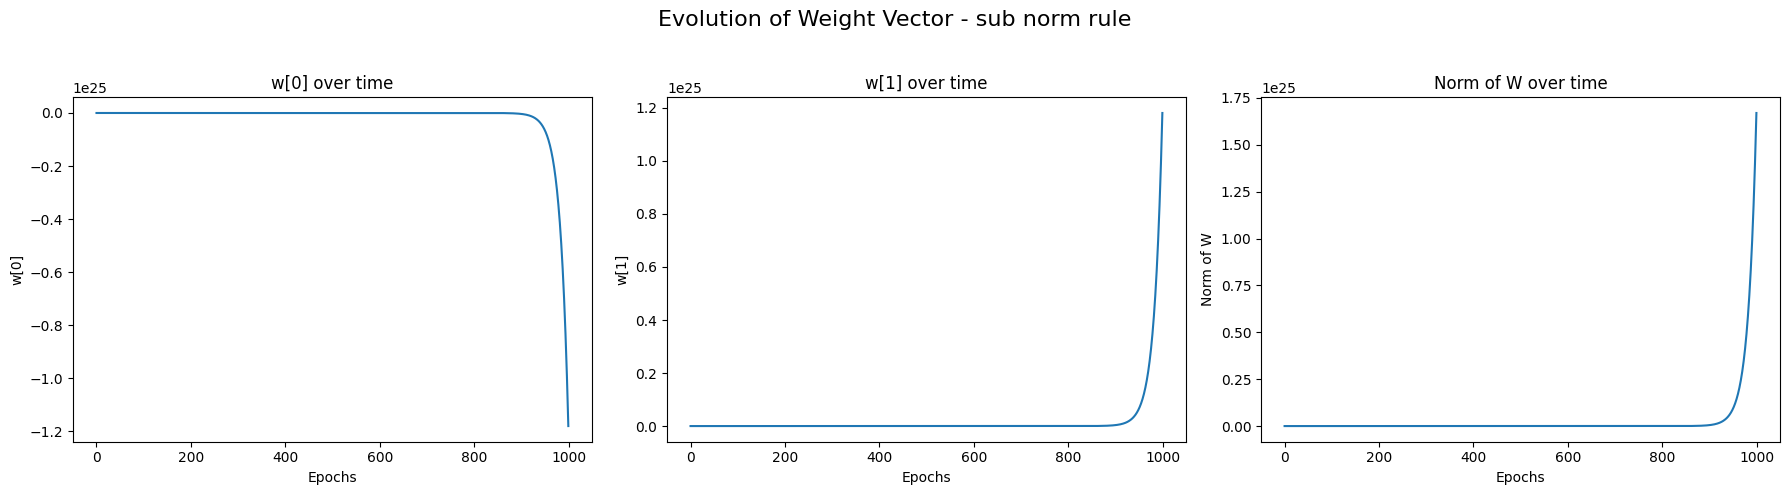

[dataset_1 | sub_norm_rule] convergence epoch=1000 | final_w=[-1.1807965e+25  1.1807965e+25]


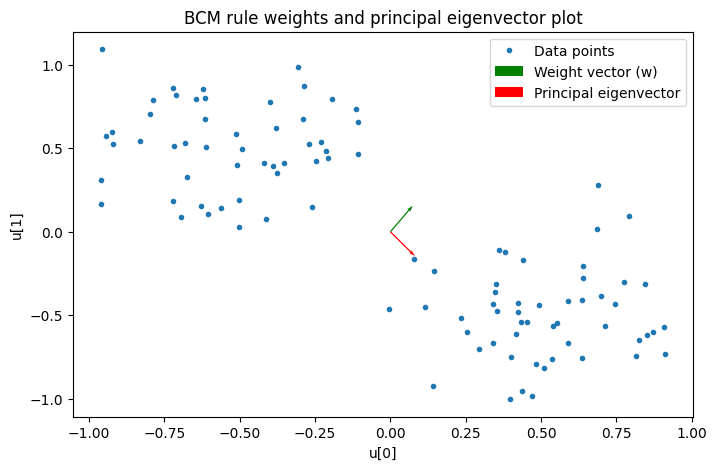

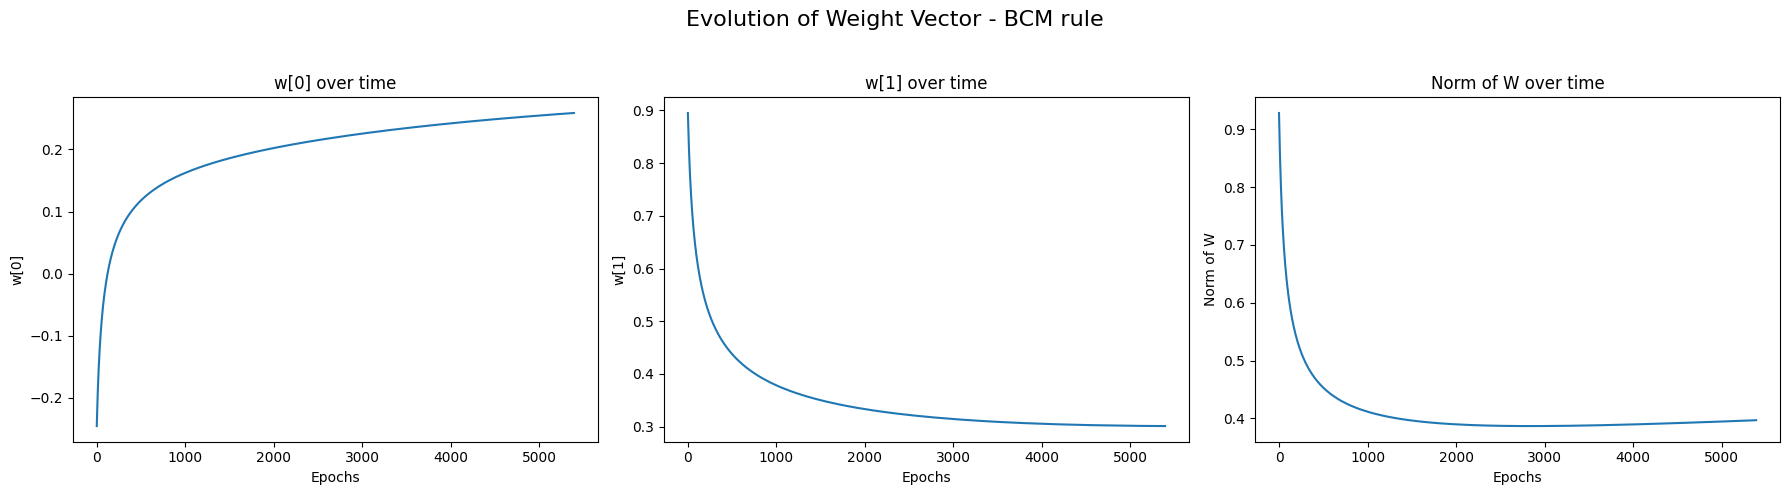

[dataset_1 | BCM_rule] convergence epoch=5392 | final_w=[0.2586 0.3011]


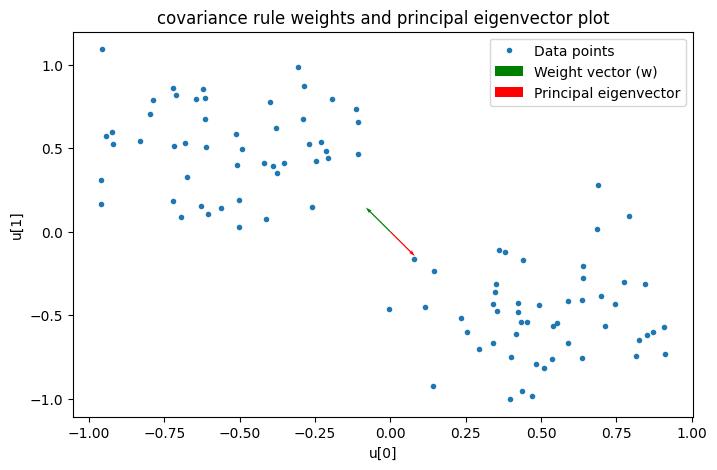

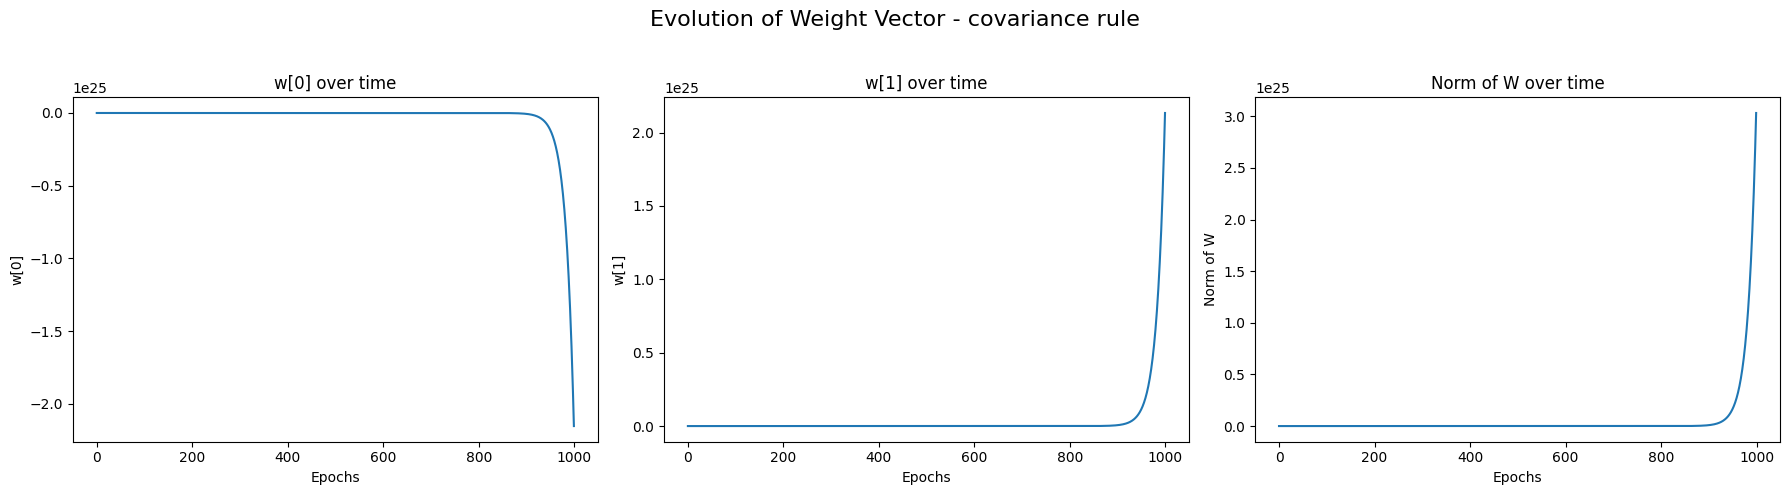

[dataset_1 | covariance_rule] convergence epoch=1000 | final_w=[-2.15351807e+25  2.13389036e+25]


In [4]:
data1 = load_dataset(PROJECT_ROOT / "data" / "lab2_1_data.csv")
inspect_dataset(data1, "lab2 dataset 1")

res1 = run_all_rules("dataset_1", data1, rule_cfg=rules_dataset1, anchor=(0.0, 0.0), seed=42)


## Dataset 2 (normalized)


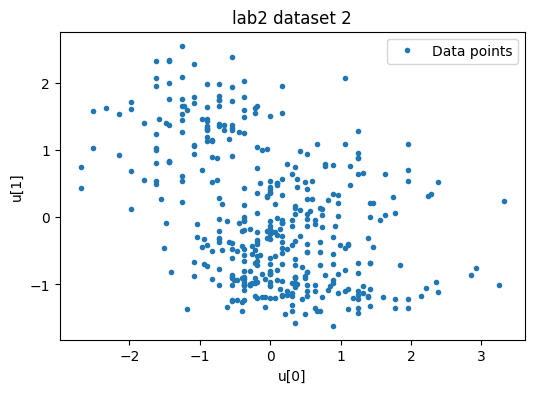

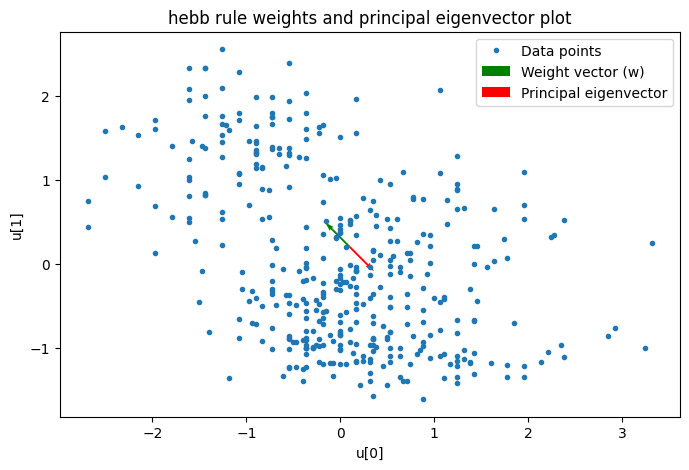

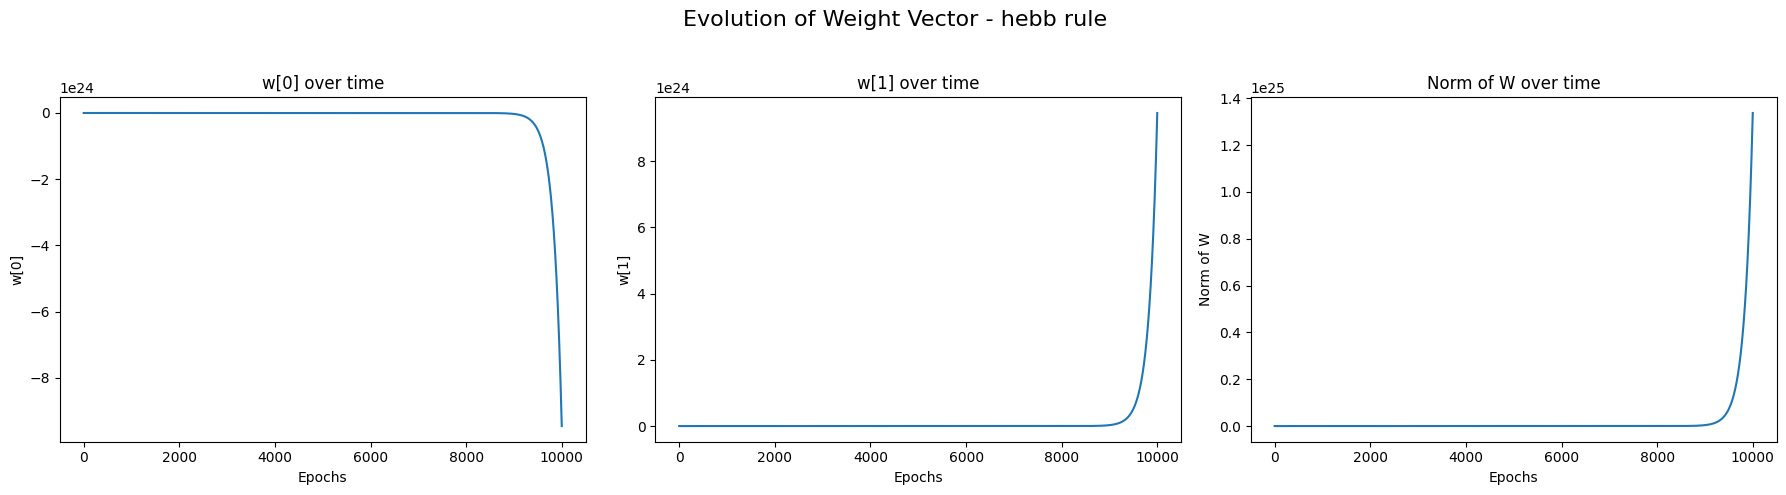

[dataset_2 | hebb_rule] convergence epoch=10000 | final_w=[-9.45795589e+24  9.45796819e+24]


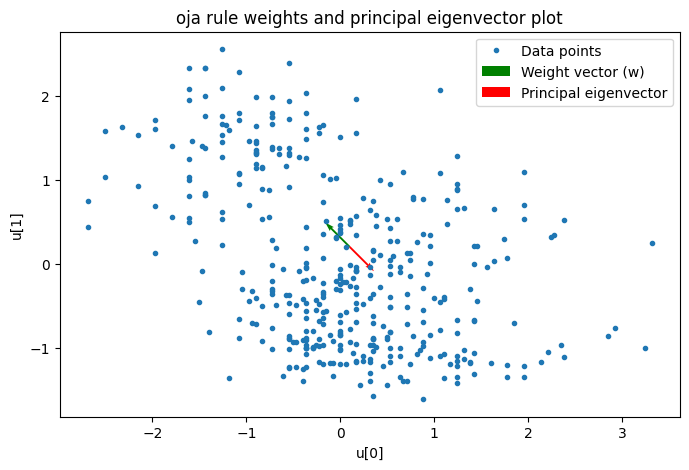

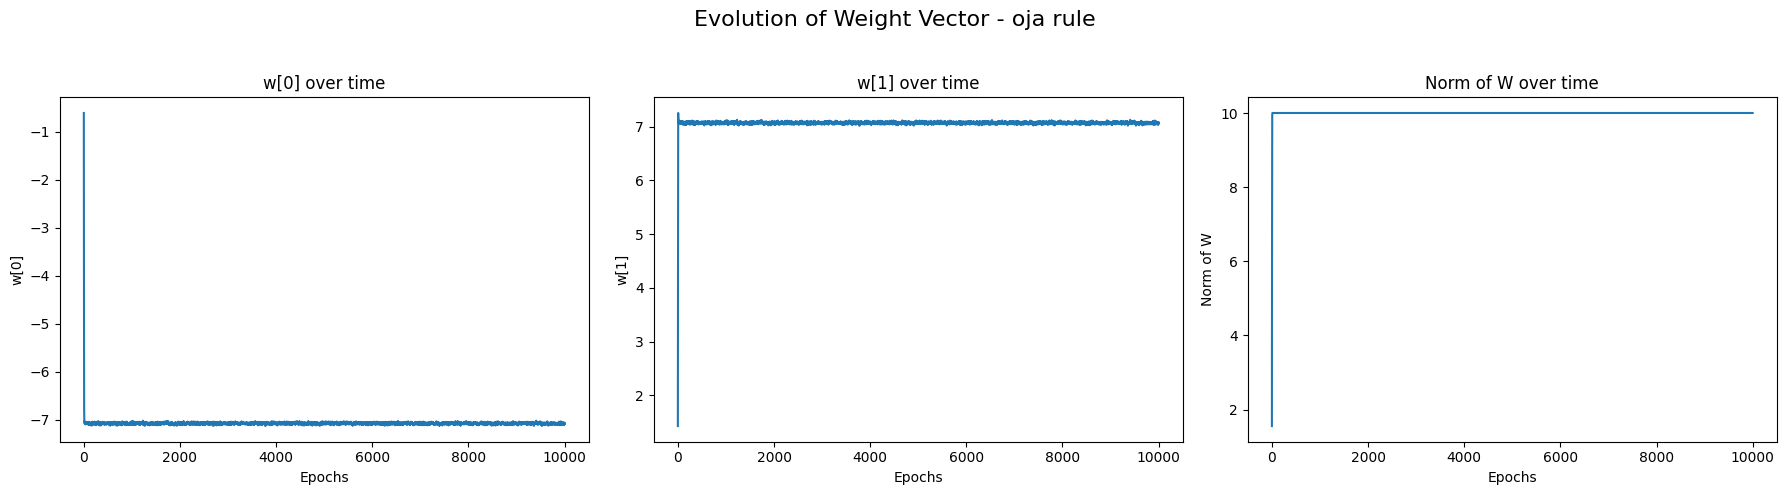

[dataset_2 | oja_rule] convergence epoch=10000 | final_w=[-7.0782  7.0661]


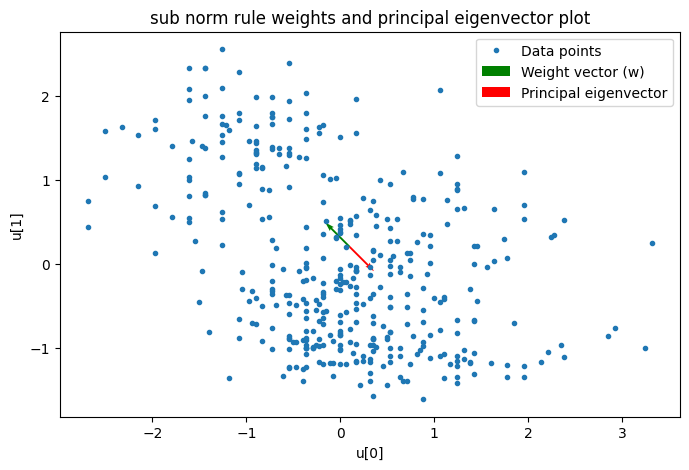

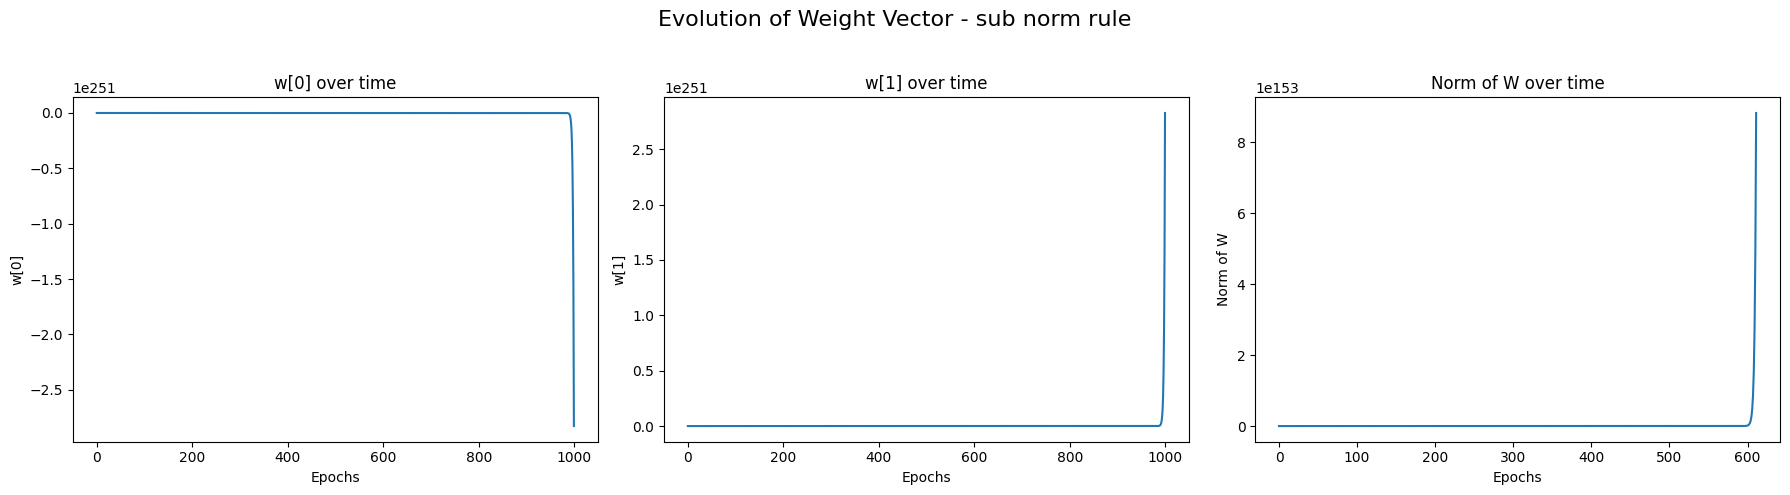

[dataset_2 | sub_norm_rule] convergence epoch=1000 | final_w=[-2.82738531e+251  2.82738531e+251]


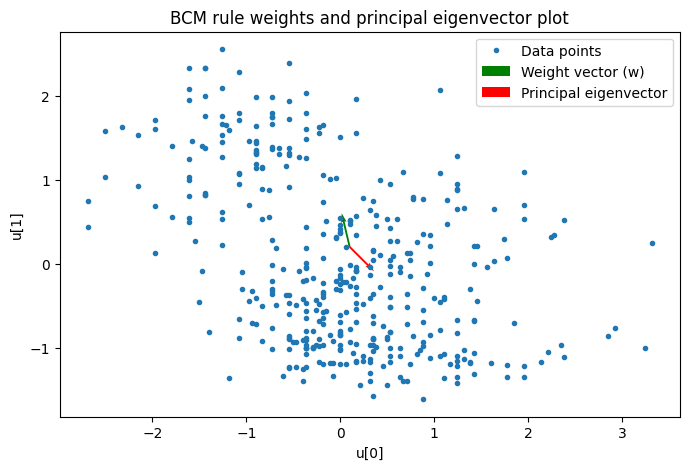

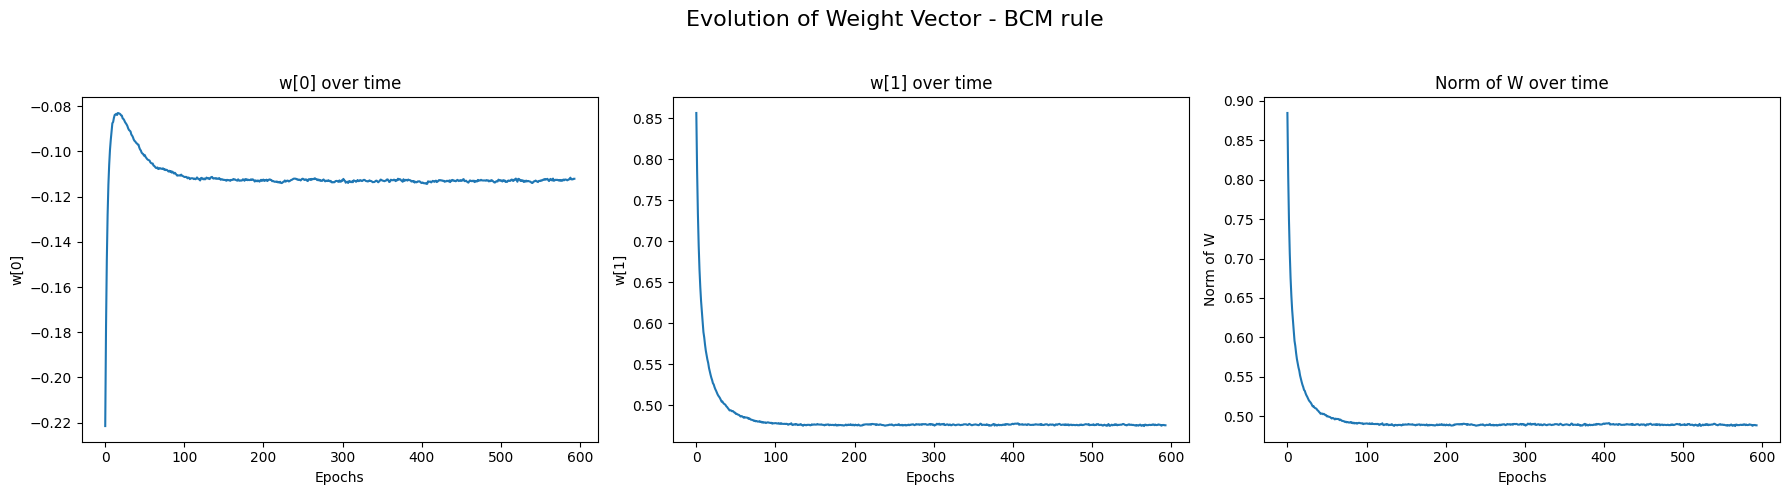

[dataset_2 | BCM_rule] convergence epoch=594 | final_w=[-0.1121  0.4753]


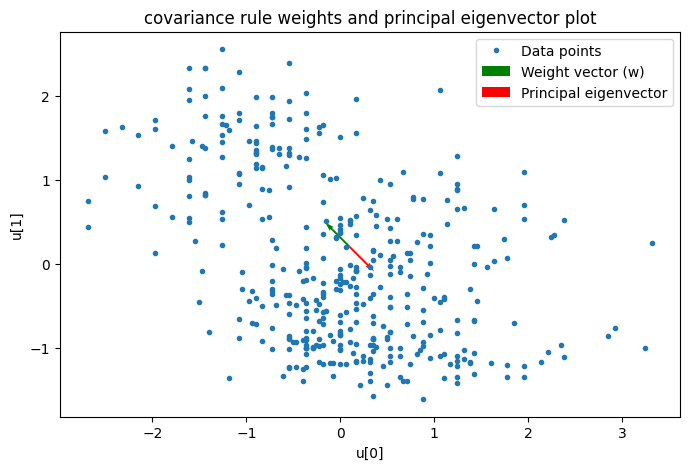

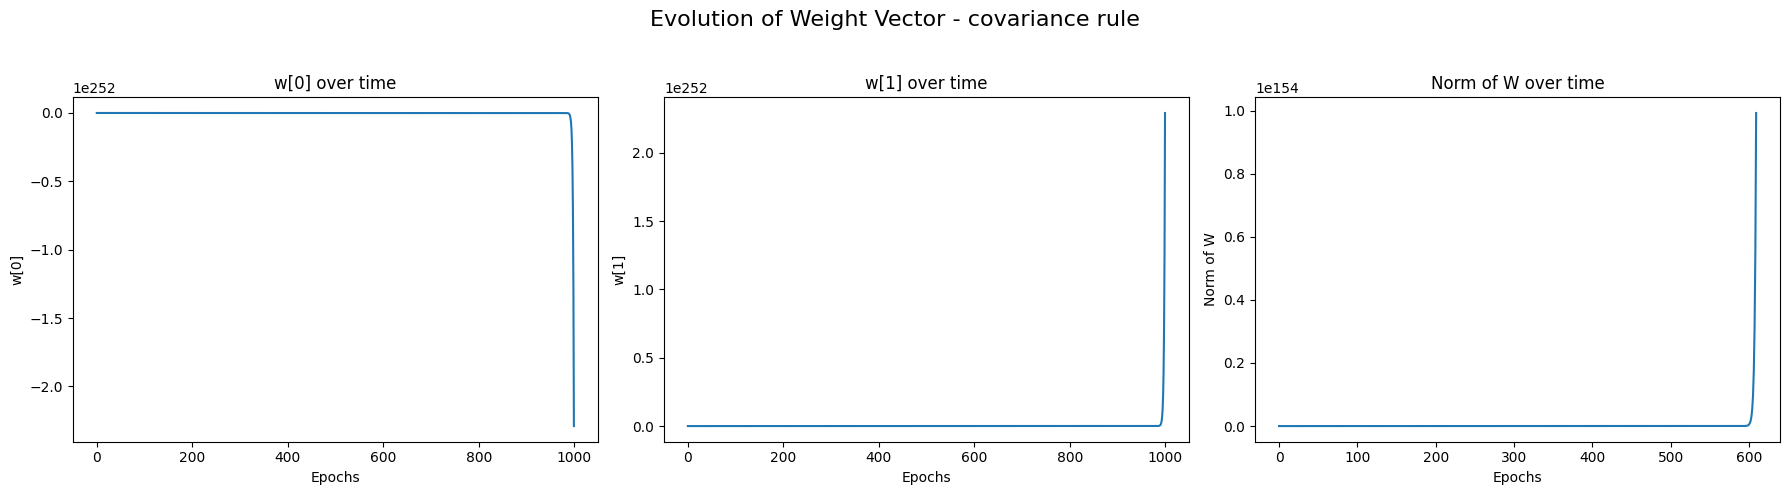

[dataset_2 | covariance_rule] convergence epoch=1000 | final_w=[-2.2906741e+252  2.2906741e+252]


In [5]:
data2_raw = load_dataset(PROJECT_ROOT / "data" / "dataset2_lab_2_1.csv")
data2 = zscore_per_feature(data2_raw)
inspect_dataset(data2, "lab2 dataset 2")

res2 = run_all_rules("dataset_2", data2, rule_cfg=rules_dataset2, anchor=(0.1, 0.2), seed=42)
